# Validation Croisée

Un problème récurrent en apprentissage automatique concerne le choix des hyperparamètres, principalement ceux qui influent sur la complexité des modèles appris, tels que le nombre de voisins pour les k-plus-proches-voisins. L'utilisation de l'erreur d'entraînement n'est pas une solution adéquate, car les k plus proches voisins ont souvent une faible erreur d'entraînement, alors que l'erreur en généralisation peut être significativement différente. De même, il ne faut pas utiliser l'erreur en généralisation, bien que ce soit la quantité que l'on cherche à minimiser. En effet, cela revient à apprendre sur l'ensemble de test, ce qui augmente considérablement le risque de surajustement.

Pour palier à ce problème, une solution est d'utiliser la validation croisée. Supposons que l'on veut choisir le meilleur paramètre $k$ (un nombre de voisins par exemple) dans l'ensemble $\{1,5,10,20,30,...\}$.
1. On sépare les données d'apprentissage en $T$ sous-ensemble de même taille (un cas particulier est $T=n$ la taille de l'échantillon et  chaque sous-ensemble est de taille $1$).
2. On sélectionne $T-1$ sous-ensemble que l'on regroupe pour apprendre un modèle avec chaque valeur de $k$ possible.
3. On calcule l'erreur des différents modèles sur le sous-ensemble n'ayant pas été utilisé pour apprendre en étape 2.
4. On répète les étapes 2. et 3. $T$ fois en sélectionnant un ensemble de validation différent à chaque fois.
5. On calcule, pour chaque valeur de $k$ possible, l'erreur moyenne obtenue sur les $T$ répétitions.
6. On sélectionne le paramètre $k$ qui minimise l'erreur moyenne et on utilise ce paramètre pour réapprendre un modèle sur l'ensemble d'apprentissage complet.

L'avantage de la validation croisée réside dans le fait qu'elle n'utilise jamais l'ensemble de test, éliminant ainsi tout risque de surajustement sur ce dernier. Au lieu de cela, la validation croisée exploite les ensembles de validation pour simuler l'apparition de nouvelles données, permettant ainsi une évaluation robuste de la performance du modèle.

Le choix du nombre de sous-ensembles $T$ assez arbitraire, une des limites principales étant que l'on ne veut pas choisir $T$ trop petit (le sous-ensebmle d'entraînement est trop petit par rapport à l'ensemble d'entraînement de départ) ni trop grand (le sous-ensemble de validation est trop petit et pas assez représentatif des données). En pratique, on choisit généralement $T=5$ ou $T=10$.

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Application de la validation croisée

### Exemple 1

In [107]:
train = pd.read_csv("../data/simpledata_train.csv")
X_train = train["x"].values[:,np.newaxis] # Matrice colonne plutôt que vecteur ligne
y_train = train["y"]
test = pd.read_csv("../data/simpledata_test.csv")
X_test = test["x"].values[:,np.newaxis] # Matrice colonne plutôt que vecteur ligne
y_test = test["y"]

#### 1.  Utiliser une validation pour sélectionner un nombre de voisins dans l'ensemble $\{1,5,10,20,30\}$ pour apprendre un modèle capable de prédire les étiquettes $y$. Pour cela utilisez la fonction `sklearn.model_selection.GridSearchCV`. Diviser les données en 5 sous-ensembles et choisir un nombre de voisins qui minimise la MSE. D'après la validation croisée, combien de voisins faut-il utiliser ?

In [108]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
#help(GridSearchCV)
cv = GridSearchCV(KNeighborsRegressor(),{"n_neighbors":[1,5,10,20,30]},cv=5,scoring="neg_mean_squared_error")
cv.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and can

In [109]:
#cv.cv_results_
cv.best_params_

{'n_neighbors': 10}

Il semble qu'utiliser 10 voisins donne les meilleurs résultats en termes de mean_test_score. C'est la valeur que l'on va sélectionner.

#### 2. Utilisez le nombre de voisins obtenu dans la question précédente pour apprendre un nouveau modèle sur l'ensemble des données d'entraînement. Calculez la MSE empirique et la MSE en généralisation.

In [110]:
reg = KNeighborsRegressor(**cv.best_params_)
reg

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [111]:
reg.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [112]:
from sklearn.metrics import mean_squared_error

print("MSE empirique : ",mean_squared_error(y_train, reg.predict(X_train)))
print("MSE en généralisation : ",mean_squared_error(y_test, reg.predict(X_test)))

MSE empirique :  18.883532809760577
MSE en généralisation :  23.703681777203002


### Exemple 2

Avec les données San_People_stats1.csv. Utiliser l'algorithme des  $𝑘$ -plus-proches-voisins pour apprendre un modèle capable de prédire prédire l'âge des individus avec les instances  height et weight. Utiliser la validation croisée pour sélection le nombre de voisins $k$.

In [113]:
import pandas as pd
import numpy as np
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import norm

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


In [114]:
dataSan = pd.read_csv("../data/San_People_stats1.csv", sep=';')
dataSanquanti=dataSan.drop(columns = 'male', axis=1)
dataSanquanti.describe()

,height,weight,age
count,544.000000,544.000000,544.000000
mean,138.263596,35.610618,29.344393
std,27.602448,14.719178,20.746888
min,53.975000,4.252425,0.000000
25%,125.095000,22.007717,12.000000
50%,148.590000,40.057844,27.000000
75%,157.480000,47.209005,43.000000
max,179.070000,62.992589,88.000000


In [115]:

X = dataSanquanti.drop('age', axis=1)
Y = dataSanquanti['age']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=1/3, random_state=53)
cv = GridSearchCV(KNeighborsRegressor(),{"n_neighbors":[1,5,10,20,30]},cv=5,scoring="neg_mean_squared_error")
cv.fit(X_train,Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and can

In [116]:
cv.best_params_

{'n_neighbors': 30}

In [117]:
reg = KNeighborsRegressor(**cv.best_params_)
reg.fit(X_train,Y_train)

print("MSE empirique : ",mean_squared_error(Y_train, reg.predict(X_train)))
print("MSE en généralisation : ",mean_squared_error(Y_test, reg.predict(X_test)))

MSE empirique :  196.46659742173117
MSE en généralisation :  188.23001642246638


### Faisons du Monte Carlo : répéter l'échantillonnage

In [118]:
repeats = 200

m_gen_errors = [] # erreurs de generalisation
m_emp_errors = [] #  erreurs d'apprentissage

for m in range(1, 10):
    gen_errors = [] # erreurs de generalisation
    emp_errors = [] # erreurs d'apprentissage
    for r in range(repeats):
        # Preprocess data
        X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=1/3)
        # Train
        knn = reg
        knn.fit(X_train, Y_train)
        # Predict
        yhat_train = knn.predict(X_train)
        emp_errors.append(mean_squared_error(Y_train, yhat_train))#mean_squared_error(y, yhat_train))
        yhat_test = knn.predict(X_test)
        gen_errors.append(mean_squared_error(Y_test, yhat_test))#mean_squared_error(y_test, yhat_test))
    m_gen_errors.append([m, np.mean(gen_errors), np.std(gen_errors)])
    m_emp_errors.append([m, np.mean(emp_errors), np.std(emp_errors)])

In [119]:
taille_train_emp_errors=pd.DataFrame(m_emp_errors, columns=["m","mean emp","std emp"])
taille_train_gen_errors=pd.DataFrame(m_gen_errors, columns=["m","mean gen","std gen"])
taille_train_gen_errors.head()

,m,mean gen,std gen
0,1,201.779953,20.048650
1,2,199.025509,21.329763
2,3,198.940194,20.062739
3,4,197.094381,21.820095
4,5,200.559622,21.040262


<Axes: xlabel='m'>

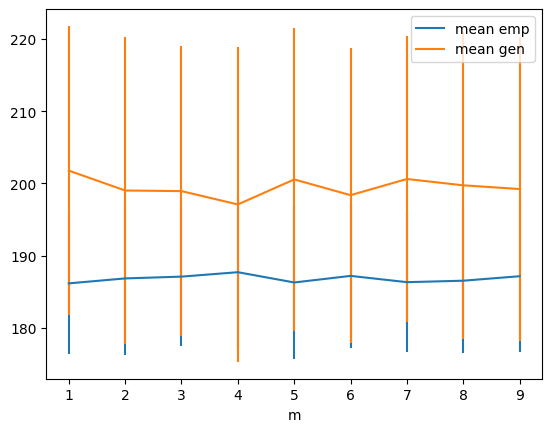

In [120]:
ax = taille_train_emp_errors.plot(kind="line",x="m",y="mean emp", yerr="std emp")
taille_train_gen_errors.plot(kind="line",x="m",y="mean gen", yerr="std gen",ax=ax)

### Exercice

Soit la base de données Boston contenant 13 attributs (criminalité, zonage, entreprises, fleuve Charles, concentration en oxydes d'azote, nombre de pièces, unités occupées par le propriétaire, distance moyenne vers les centres d'emploi, accessibilité aux autoroutes radiales, taux d'imposition, ratio élève/enseignant, pourcentage de statut inférieur, valeur médiane des résidences occupées par le propriétaire) et 506 entrées. Utiliser l'algorithme des  $𝑘$- plus-proches-voisins pour apprendre un modèle capable de prédire prédire le taux de criminalité en fonction des autres attributs (faites au préalable une analyse descriptive des attributs, une sélection des attributs pour un meilleur modèle). Utiliser la validation croisée pour sélection le nombre de voisins $k$.


In [121]:
dataBoston = pd.read_csv("../data/Boston.csv", sep=',')
dataBoston.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [122]:
import pandas as pd
import numpy as np
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import norm
from sklearn.linear_model import LinearRegression
from matplotlib import cm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, explained_variance_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn import neighbors

In [123]:
X_Boston = dataBoston.drop('crim', axis=1)
Y_Boston = dataBoston['crim']
X_train_Boston, X_test_Boston, Y_train_Boston, Y_test_Boston = train_test_split(X_Boston, Y_Boston, test_size=1/5, random_state=53)


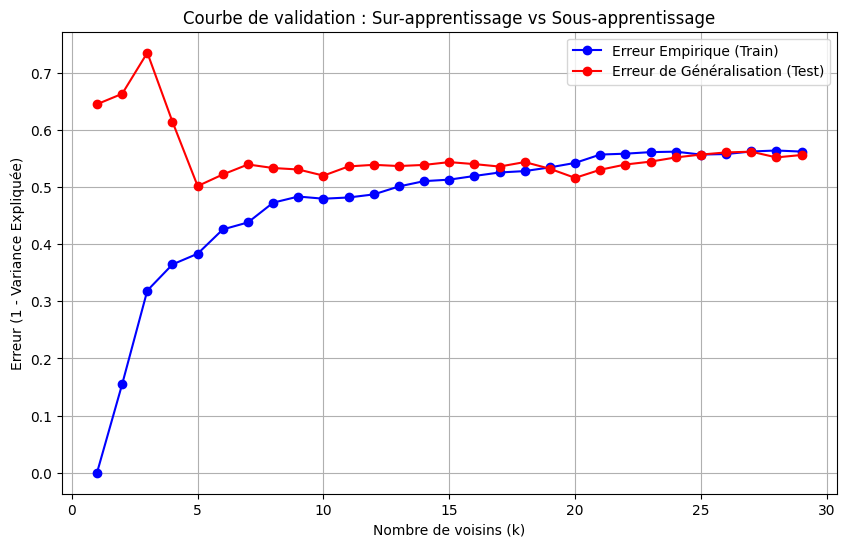

In [124]:
# Listes pour stocker les scores
gen_errors = [] # Erreur sur le test (Généralisation)
emp_errors = [] # Erreur sur le train (Empirique)
k_vals = list(range(1, 30))

for k in k_vals:
    # modèle knn avec le k
    model_knn = neighbors.KNeighborsRegressor(n_neighbors=k)
    # Entraînement du modele
    model_knn.fit(X_train_Boston, Y_train_Boston)
    #prédiction et calcul de l'erreur sur le TRAIN (Empirique)
    yhat_train = model_knn.predict(X_train_Boston)
    # On utilise 1 - score de la variance expliquée pour avoir l'erreur (0 est parfait, 1 est mauvais)
    emp_errors.append(1 - explained_variance_score(Y_train_Boston, yhat_train))
    #prédiction et calcul de l'erreur sur le TEST (Généralisation)
    yhat_test = model_knn.predict(X_test_Boston)
    gen_errors.append(1 - explained_variance_score(Y_test_Boston, yhat_test))

# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(k_vals, emp_errors, label='Erreur Empirique (Train)', marker='o', color='blue')
plt.plot(k_vals, gen_errors, label='Erreur de Généralisation (Test)', marker='o', color='red')

plt.xlabel('Nombre de voisins (k)')
plt.ylabel('Erreur (1 - Variance Expliquée)')
plt.title('Courbe de validation : Sur-apprentissage vs Sous-apprentissage')
plt.legend()
plt.grid(True)
plt.show()

In [125]:
cv_Boston = GridSearchCV(KNeighborsRegressor(),{"n_neighbors":[5,6, 7, 8, 9, 10,11, 12, 13, 14, 15, 16, 17]},cv=10,scoring="neg_mean_squared_error")
cv_Boston.fit(X_train_Boston,Y_train_Boston)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [5, 6, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and ca

In [126]:
cv_Boston.best_params_

{'n_neighbors': 10}

In [143]:
for i in range(2, 10):
  cv_Boston = GridSearchCV(KNeighborsRegressor(),{"n_neighbors":[5,6, 7, 8, 9, 10,11, 12, 13, 14, 15, 16, 17]},cv=i,scoring="neg_mean_squared_error")
  cv_Boston.fit(X_train_Boston,Y_train_Boston)
  print(i,cv_Boston.best_params_)


2 {'n_neighbors': 13}
3 {'n_neighbors': 14}
4 {'n_neighbors': 14}
5 {'n_neighbors': 15}
6 {'n_neighbors': 16}
7 {'n_neighbors': 16}
8 {'n_neighbors': 16}
9 {'n_neighbors': 16}


In [144]:
repeats = 10
k_rep = []
m_gen_errors = [] # erreurs de generalisation
m_emp_errors = [] #  erreurs d'apprentissage

for m in range(1, 10):
    gen_errors = [] # erreurs de generalisation
    emp_errors = [] # erreurs d'apprentissage
    k_rep2 = []
    for r in range(repeats):
        # Preprocess data
        X_train_Boston, X_test_Boston, Y_train_Boston, Y_test_Boston = train_test_split(X_Boston, Y_Boston, test_size=1/5)
        # Train
        cv_Boston = GridSearchCV(KNeighborsRegressor(),{"n_neighbors":[5,6, 7, 8, 9, 10,11, 12, 13, 14, 15, 16, 17]},cv=10,scoring="neg_mean_squared_error")
        cv_Boston.fit(X_train_Boston,Y_train_Boston)
        kopt = cv_Boston.best_params_["n_neighbors"]
        model_knn = neighbors.KNeighborsRegressor(n_neighbors=kopt)
        model_knn.fit(X_train_Boston, Y_train_Boston)
        # Predict
        yhat_train = model_knn.predict(X_train_Boston)
        emp_errors.append(mean_squared_error(Y_train_Boston, yhat_train))#mean_squared_error(y, yhat_train))
        yhat_test = model_knn.predict(X_test_Boston)
        gen_errors.append(mean_squared_error(Y_test_Boston, yhat_test))#mean_squared_error(y_test, yhat_test))
        k_rep2.append(kopt)
    m_gen_errors.append([m, np.mean(gen_errors), np.std(gen_errors)])
    m_emp_errors.append([m, np.mean(emp_errors), np.std(emp_errors)])
    k_rep.append([m, k_rep2])


In [141]:
taille_train_emp_errors=pd.DataFrame(m_emp_errors, columns=["m","mean emp","std emp"])
taille_train_gen_errors=pd.DataFrame(m_gen_errors, columns=["m","mean gen","std gen"])
taille_train_emp_errors.head(10)

,m,mean emp,std emp
0,1,34.784912,6.410025
1,2,36.287888,7.304297
2,3,35.252194,6.164545
3,4,37.234447,6.776363
4,5,32.006709,6.304118
5,6,30.166414,5.502521
6,7,34.576911,9.498571
7,8,35.419630,4.808468
8,9,38.368273,7.251421


In [146]:
k_rep[1]

[2, [17, 6, 6, 12, 10, 6, 11, 8, 7, 8]]

In [148]:
print(k_rep[0][1])
print(len(k_rep[0][1]))
import statistics
finals_k = []
for rep in k_rep:
    m = rep[0]
    k_values = [k for k in rep[1]]
    mode_k = statistics.mode(k_values)
    finals_k.append([m, mode_k])
finals_k

finals_k = [mode[1] for mode in finals_k]
err_gen = taille_train_gen_errors["mean gen"]
err_emp= taille_train_emp_errors["mean emp"]

[5, 13, 12, 10, 5, 10, 14, 17, 10, 8]
10


In [149]:
for i in range(len(finals_k)):
   for j in range(i+1, len(finals_k)):
       if finals_k[i] >= finals_k[j]:
           temp_k = finals_k[i]
           finals_k[i] = finals_k[j]
           finals_k[j] = temp_k
           
           temp_err_gen = err_gen[i]
           err_gen[i] = err_gen[j]
           err_gen[j] = temp_err_gen
           
           temp_err_emp = err_emp[i]
           err_emp[i] = err_emp[j]
           err_emp[j] = temp_err_emp
print(finals_k)
  

[6, 7, 9, 9, 10, 11, 11, 16, 17]


/tmp/ipykernel_7926/3826639930.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  err_gen[i] = err_gen[j]
/tmp/ipykernel_7926/3826639930.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  err_gen[j] = temp_err_gen
/tmp/ipykernel_7926/3826639930.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  err_emp[i] = err_emp[j]
/tmp/ipykernel_7926/3826639930.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fr

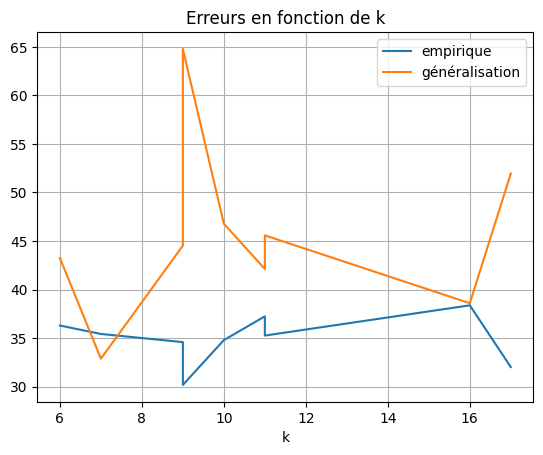

In [150]:
k_errors = pd.DataFrame({"k":finals_k,"empirique":err_emp,"généralisation":err_gen})
ax=k_errors.plot(kind="line",x="k",y="empirique")
k_errors.plot(kind="line",x="k",y="généralisation", ax=ax)
plt.title("Erreurs en fonction de k")
plt.grid()
plt.legend()